In [ ]:
from google.colab import files
files.upload()



Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"malavikavinodpp","key":"0c74ae9e7dacaf11f1f7effb29bec904"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download and unzip dataset
!kaggle datasets download -d uciml/sms-spam-collection-dataset
!unzip sms-spam-collection-dataset.zip



Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
  0% 0.00/211k [00:00<?, ?B/s]
100% 211k/211k [00:00<00:00, 404MB/s]
Archive:  sms-spam-collection-dataset.zip
  inflating: spam.csv                


In [ ]:
#  STEP 3: Load the dataset
import pandas as pd

# Load CSV and rename relevant columns
df = pd.read_csv("spam.csv", encoding='latin-1')[['v1', 'v2']]
df.columns = ['label', 'message']

# Convert 'ham'/'spam' to 0/1
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

df.head()


,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
import re
import string

def clean_text(text):
    text = text.lower()
    text = re.sub(r'\[.*?\]', '', text)                                   # remove [brackets]
    text = re.sub(r'\w*\d\w*', '', text)                                  # remove words with numbers
    text = re.sub(f"[{re.escape(string.punctuation)}]", '', text)         # remove punctuation
    text = re.sub(r'\n', '', text)                                        # remove newlines
    return text

df['message'] = df['message'].apply(clean_text)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [ ]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train_vec, y_train)


MultinomialNB()

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9506726457399103
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       965
           1       1.00      0.63      0.78       150

    accuracy                           0.95      1115
   macro avg       0.97      0.82      0.87      1115
weighted avg       0.95      0.95      0.95      1115



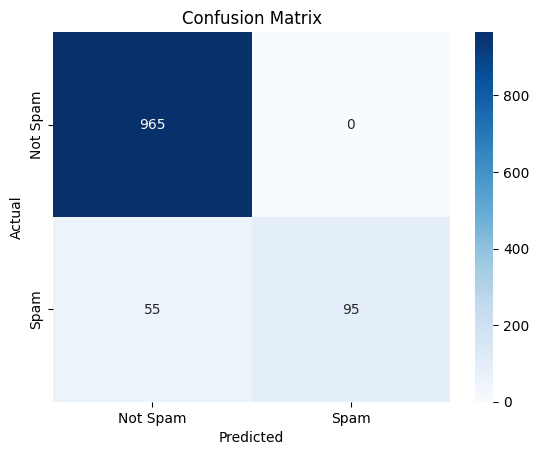

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Spam', 'Spam'],
            yticklabels=['Not Spam', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
def predict_message(msg):
    cleaned = clean_text(msg)
    vector = vectorizer.transform([cleaned])
    pred = model.predict(vector)
    return "🟥 Spam" if pred[0] else "🟩 Not Spam"

# Test it
print(predict_message("Claim your FREE prize now! Call 12345"))
print(predict_message("Hey, are we meeting today?"))


🟥 Spam
🟩 Not Spam


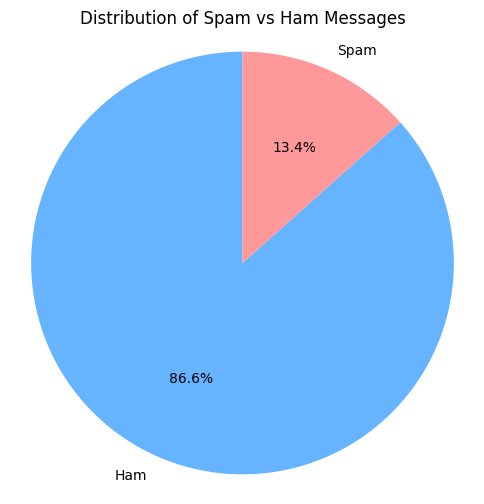

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Count the number of spam and ham messages
label_counts = df['label'].value_counts()

# Map the label values back to readable form (optional)
label_names = ['Ham', 'Spam']  # 0 = Ham, 1 = Spam

# Create a pie chart
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_names, autopct='%1.1f%%', startangle=90, colors=["#66b3ff", "#ff9999"])
plt.title('Distribution of Spam vs Ham Messages')
plt.axis('equal')  # Ensures the pie is a circle
plt.show()

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Split first
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42)

# Vectorize (convert text to numbers)
vectorizer = TfidfVectorizer(ngram_range=(1,2))  # unigrams and bigrams
X_train_vec = vectorizer.fit_transform(X_train_raw)
X_test_vec = vectorizer.transform(X_test_raw)

# Apply SMOTE only AFTER vectorization
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_train_vec, y_train)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_resampled, y_resampled)


LogisticRegression()

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced')
model.fit(X_train_vec, y_train)


LogisticRegression(class_weight='balanced')

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(class_weight='balanced')
model.fit(X_train_vec, y_train)


RandomForestClassifier(class_weight='balanced')

In [ ]:
# Predict probabilities instead of classes
probs = model.predict_proba(X_test_vec)[:, 1]


threshold = 0.3
preds = (probs >= threshold).astype(int)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(ngram_range=(1, 2))  # unigrams + bigrams
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Split the data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    df['message'], df['label'], test_size=0.2, random_state=42)

# Vectorizer
vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train_raw)


X_train_vec_dense = X_train_vec.toarray()

# Apply SMOTE
smote = SMOTE()
X_resampled, y_resampled = smote.fit_resample(X_train_vec_dense, y_train)

# Train model
model = RandomForestClassifier()
model.fit(X_resampled, y_resampled)

# Vectorize test set (using same vectorizer)
X_test_vec = vectorizer.transform(X_test_raw)

# Evaluate
print("Accuracy:", model.score(X_test_vec, y_test))


Accuracy: 0.9730941704035875


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9730941704035875
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.80      0.89       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.94      1115
weighted avg       0.97      0.97      0.97      1115



In [ ]:
print(predict_message("text me back"))

🟩 Not Spam
